# XForecast data analysis and leakage-safe feature engineering with Polars

This notebook implements the analysis and feature-engineering plan in `latex/main.tex` using Polars for all tabular work. It uses only competition-provided market data and text-embedding identifiers.

**Observed full training-set facts:** 104,400 stock-date rows, 100 tickers, and 1,044 dates from 2019-01-01 through 2022-12-30. The panel contains 100 tickers on every date. For a 20-trading-day endpoint, 102,400 labels are available and 58.99% are upward. OHLC prices are positive and internally consistent; volume has two non-positive observations. Each row has 18.24 of 21 text fields populated on average.

**Memory safety:** market parquet files can be scanned directly, but individual embedding files are 0.4--13 GB. Every valid embedding model is exposed as a lazy Polars scan with all dimensions intact. Materialization and optional fold-specific PCA are streamed one model at a time; collecting every dense embedding matrix simultaneously would exceed ordinary workstation memory.


In [36]:
# pip install numpy polars matplotlib pyarrow scikit-learn

In [37]:
from pathlib import Path
import json
import gc
import warnings

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from sklearn.decomposition import IncrementalPCA
import joblib

pl.Config.set_tbl_cols(100)
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path("data")
USE_SAMPLE = False                # set True only for a quick 300-row smoke test
HORIZON = 20                       # approximately four trading weeks
WINDOWS = (5, 10, 20, 40, 60)
TRADING_WEEK_FOURIER_HARMONICS = 2
MONTH_OF_YEAR_FOURIER_HARMONICS = 2
TRADING_MONTH_FOURIER_HARMONICS = 3
EMBEDDING_EXPORT = "pca_embeddings"       # no_embeddings | original_embeddings | pca_embeddings
EMBEDDING_MODELS = ("bert") #"nvda", "lgai", "linq",  "qwen", "gemini"
PCA_COMPONENTS = 32
if EMBEDDING_EXPORT not in {"no_embeddings", "original_embeddings", "pca_embeddings"}:
    raise ValueError("EMBEDDING_EXPORT must be no_embeddings, original_embeddings, or pca_embeddings.")
LOAD_EMBEDDINGS = EMBEDDING_EXPORT != "no_embeddings"
PCA_COMPONENTS_BY_MODEL = {
    model: (PCA_COMPONENTS if EMBEDDING_EXPORT == "pca_embeddings" else None)
    for model in EMBEDDING_MODELS
}
PCA_BATCH_SIZE = 4096
SAVE_ARTIFACTS = True               # persist reusable training artifacts
ARTIFACT_DIR = DATA_DIR / "model_artifacts" / EMBEDDING_EXPORT
RANDOM_STATE = 42


## 1. File inventory and integrity

This checks file sizes and parquet footers without loading large embedding matrices. A failed footer usually indicates a partial download.


In [38]:
def parquet_metadata(path):
    try:
        pf = pq.ParquetFile(path)
        return {
            "status": "ok",
            "rows": pf.metadata.num_rows,
            "columns": pf.metadata.num_columns,
            "row_groups": pf.metadata.num_row_groups,
        }
    except Exception as exc:
        return {
            "status": f"ERROR: {type(exc).__name__}: {exc}",
            "rows": None, "columns": None, "row_groups": None,
        }

inventory = []
for path in sorted(DATA_DIR.glob("*")):
    if not path.is_file():
        continue
    row = {"file": path.name, "size_gb": path.stat().st_size / 1024**3}
    if path.suffix == ".parquet":
        row.update(parquet_metadata(path))
    inventory.append(row)

inventory_df = pl.DataFrame(inventory, infer_schema_length=None).sort("size_gb", descending=True)
display(inventory_df)
bad_parquet = (
    inventory_df.filter(pl.col("status").fill_null("").str.starts_with("ERROR"))
    .get_column("file").to_list()
)
if bad_parquet:
    print("Incomplete/corrupt parquet files (skip or re-download):", bad_parquet)


file,size_gb,status,rows,columns,row_groups
str,f64,str,i64,i64,i64
"""nvda_textemb.parquet""",13.234934,"""ok""",588905,4097,30
"""qwen_textemb.parquet""",13.234821,"""ok""",588905,4097,30
"""lgai_textemb.parquet""",13.234243,"""ok""",588905,4097,30
"""gemini_textemb.parquet""",9.926819,"""ok""",588905,3073,30
"""bert_textemb.parquet""",1.244144,"""ok""",588905,385,30
…,…,…,…,…,…
"""train.parquet""",0.007334,"""ok""",104400,28,1
"""text_sample.csv""",0.002605,null,null,null,null
"""bert_textemb_sample.csv""",0.001318,null,null,null,null


Incomplete/corrupt parquet files (skip or re-download): ['linq_textemb.parquet']


## 2. Load and audit the market panel

The notebook does not download data. It uses files already under `data/`.


In [39]:
market_path = DATA_DIR / ("train_sample.csv" if USE_SAMPLE else "train.parquet")
test_path = DATA_DIR / ("test_sample.csv" if USE_SAMPLE else "test.parquet")
market = (
    pl.read_csv(market_path, try_parse_dates=True)
    if market_path.suffix == ".csv"
    else pl.read_parquet(market_path)
)
test_market = (
    pl.read_csv(test_path, try_parse_dates=True)
    if test_path.suffix == ".csv"
    else pl.read_parquet(test_path)
)
market = market.with_columns(pl.col("date").cast(pl.Date)).sort(["ticker", "date"])
test_market = test_market.with_columns(pl.col("date").cast(pl.Date)).sort(["ticker", "date"])

ID_COLS = ["date", "ticker"]
PRICE_COLS = ["open", "high", "low", "close", "volume"]
TEXT_ID_COLS = [c for c in market.columns if c not in ID_COLS + PRICE_COLS]
assert test_market.columns == market.columns, "Train/test schemas differ before target construction."

print(f"shape={market.shape}, tickers={market['ticker'].n_unique()}, dates={market['date'].n_unique()}")
print(f"date range: {market['date'].min()} to {market['date'].max()}")
print(f"text-ID fields: {len(TEXT_ID_COLS)}")
print(f"test shape={test_market.shape}, dates={test_market['date'].n_unique()}, range={test_market['date'].min()} to {test_market['date'].max()}")
display(market.head())


shape=(104400, 28), tickers=100, dates=1044
date range: 2019-01-01 to 2022-12-30
text-ID fields: 21
test shape=(128400, 28), dates=1284, range=2019-01-01 to 2023-12-01


date,ticker,open,high,low,close,volume,macro_category1,macro_category2,macro_category3,macro_category4,macro_category5,sector_category1,sector_category2,sector_category3,sector_category4,sector_category5,targetCompany_category1,targetCompany_category2,targetCompany_category3,relatedCompany_category1,relatedCompany_category2,relatedCompany_category3,filing_financialStatement,filing_governanceRisks,filing_overviewProduct,filing_recentEventCatalyst,filing_strategyMarketOps
date,str,f32,f32,f32,f32,f32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
2019-01-01,"""AAPL""",37.648598,37.845715,37.161755,37.460987,1.40014e8,"""text_138154""","""text_437596""","""text_242014""","""text_369412""",null,null,null,null,null,null,null,null,null,"""text_323198""","""text_436004""","""text_319284""","""text_202273""","""text_186094""",null,"""text_29057""",null
2019-01-02,"""AAPL""",36.784149,37.724594,36.627407,37.503731,1.481588e8,"""text_157810""","""text_13991""","""text_234697""","""text_365043""","""text_374416""","""text_61097""","""text_187561""","""text_352740""","""text_406091""","""text_399034""","""text_87730""","""text_435483""","""text_8976""","""text_188742""","""text_279101""","""text_89404""","""text_202273""","""text_186094""",null,"""text_29057""",null
2019-01-03,"""AAPL""",34.193176,34.606403,33.722954,33.768078,3.652488e8,"""text_422859""","""text_342356""","""text_243142""","""text_171326""","""text_399074""","""text_262002""","""text_59942""","""text_177078""","""text_318413""","""text_186954""","""text_394115""","""text_376193""","""text_8400""","""text_366206""","""text_59611""","""text_422921""","""text_202273""","""text_186094""",null,"""text_29057""",null
2019-01-04,"""AAPL""",34.323799,35.278492,34.150433,35.209618,2.344284e8,"""text_111455""","""text_138214""","""text_247571""","""text_359897""","""text_20113""","""text_377652""","""text_199719""","""text_174342""","""text_133359""","""text_352482""","""text_419168""","""text_437591""","""text_308796""","""text_66014""","""text_320715""","""text_455423""","""text_202273""","""text_186094""",null,"""text_29057""",null
2019-01-07,"""AAPL""",35.31411,35.344982,34.649151,35.131245,2.191112e8,"""text_122908""","""text_36311""","""text_465127""","""text_115805""","""text_103925""","""text_195886""","""text_85232""","""text_428461""","""text_250206""","""text_280079""","""text_76413""","""text_400172""","""text_411331""","""text_305496""","""text_363263""","""text_74898""","""text_202273""","""text_186094""",null,"""text_29057""",null


In [40]:
audit = pl.DataFrame({
    "check": [
        "rows", "duplicate ticker-date rows", "non-positive OHLC rows",
        "inconsistent OHLC rows", "missing volume rows", "non-positive volume rows",
    ],
    "value": [
        market.height,
        market.select(pl.struct(["ticker", "date"]).is_duplicated().sum()).item(),
        market.select(pl.any_horizontal([pl.col(c) <= 0 for c in ["open", "high", "low", "close"]]).sum()).item(),
        market.select(((pl.col("high") < pl.max_horizontal("open", "close", "low")) | (pl.col("low") > pl.min_horizontal("open", "close", "high"))).sum()).item(),
        market["volume"].null_count(),
        market.select((pl.col("volume") <= 0).sum()).item(),
    ],
})
display(audit)

rows_per_ticker = market.group_by("ticker").len()["len"]
tickers_per_date = market.group_by("date").agg(pl.col("ticker").n_unique().alias("n"))["n"]
display(pl.DataFrame({
    "statistic": ["min", "mean", "max"],
    "rows_per_ticker": [float(rows_per_ticker.min()), float(rows_per_ticker.mean()), float(rows_per_ticker.max())],
    "tickers_per_date": [float(tickers_per_date.min()), float(tickers_per_date.mean()), float(tickers_per_date.max())],
}))


check,value
str,i64
"""rows""",104400
"""duplicate ticker-date rows""",0
"""non-positive OHLC rows""",0
"""inconsistent OHLC rows""",0
"""missing volume rows""",0
"""non-positive volume rows""",2


statistic,rows_per_ticker,tickers_per_date
str,f64,f64
"""min""",1044.0,100.0
"""mean""",1044.0,100.0
"""max""",1044.0,100.0


field,missing_fraction
str,f64
"""targetCompany_category3""",0.879895
"""targetCompany_category2""",0.787538
"""targetCompany_category1""",0.620709
"""sector_category5""",0.154866
"""sector_category4""",0.090498
…,…
"""volume""",0.0
"""macro_category1""",0.0
"""macro_category2""",0.0


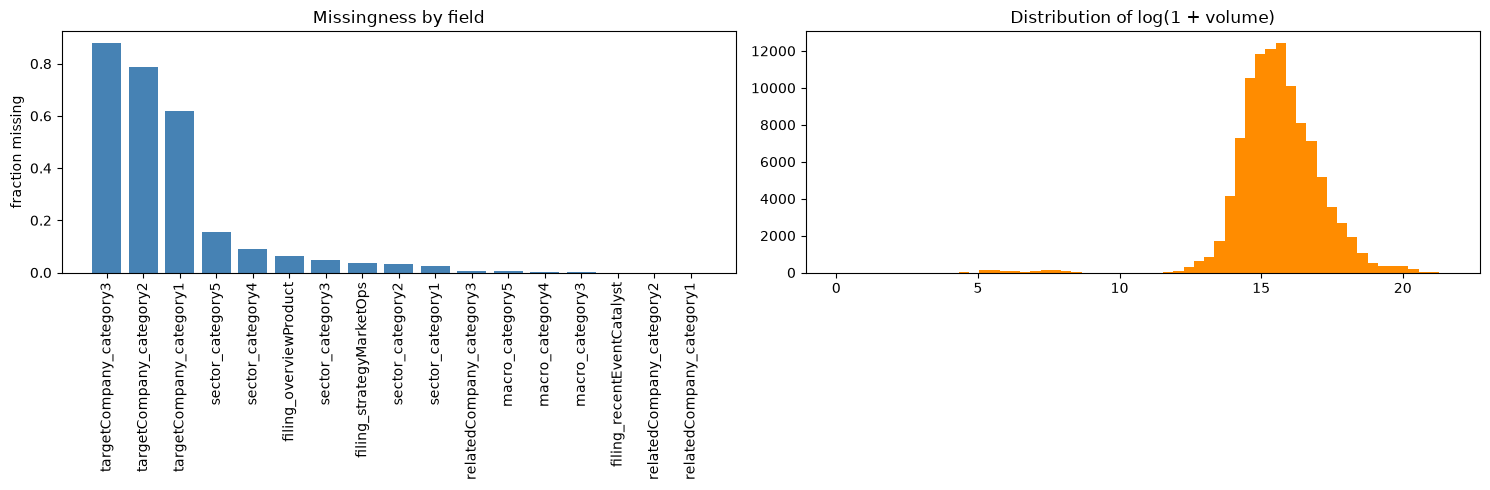

In [41]:
missing_df = pl.DataFrame({
    "field": market.columns,
    "missing_fraction": [market[c].null_count() / market.height for c in market.columns],
}).sort("missing_fraction", descending=True)
display(missing_df)

missing_nonzero = missing_df.filter(pl.col("missing_fraction") > 0)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(missing_nonzero["field"].to_list(), missing_nonzero["missing_fraction"].to_numpy(), color="steelblue")
axes[0].tick_params(axis="x", rotation=90)
axes[0].set_title("Missingness by field")
axes[0].set_ylabel("fraction missing")
volume_plot = market.select(pl.col("volume").clip(lower_bound=0).log1p()).to_series().drop_nulls().to_numpy()
axes[1].hist(volume_plot, bins=60, color="darkorange")
axes[1].set_title("Distribution of log(1 + volume)")
plt.tight_layout()


## 3. Four-week endpoint target

For stock $i$ and forecast origin $t$, the label is one when the close at $t+H$ exceeds the close at $t$. With daily trading observations, $H=20$. The last 20 rows of every ticker have unknown training labels and remain available for inference-style feature construction.


available_labels,up_rate,mean_return,return_std,q05,median,q95
u32,f32,f32,f32,f32,f32,f32
102400,0.589863,0.011166,0.097318,-0.13998,0.01647,0.15059


year,up_rate,count
i32,f32,u32
2019,0.675862,26100
2020,0.615954,26200
2021,0.598506,26100
2022,0.458458,24000


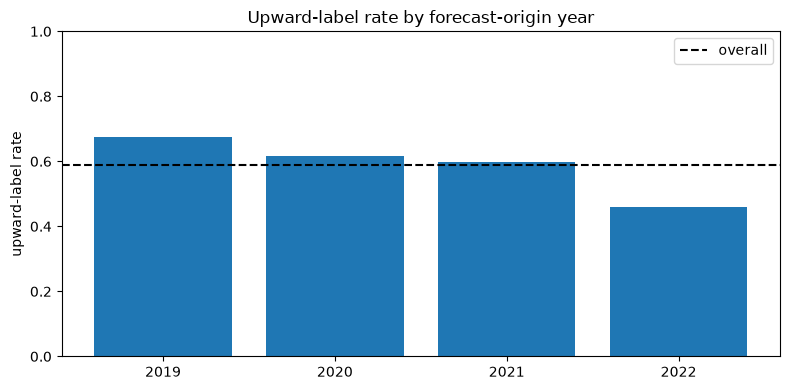

In [42]:
market = market.with_columns(
    pl.col("close").shift(-HORIZON).over("ticker").alias("future_close")
).with_columns(
    (pl.col("future_close") / pl.col("close")).log().alias("fwd_log_return_20"),
    pl.when(pl.col("future_close").is_not_null())
      .then((pl.col("future_close") > pl.col("close")).cast(pl.Float32))
      .otherwise(None).alias("target_up"),
).drop("future_close")

target_summary = market.select(
    pl.col("fwd_log_return_20").count().alias("available_labels"),
    pl.col("target_up").mean().alias("up_rate"),
    pl.col("fwd_log_return_20").mean().alias("mean_return"),
    pl.col("fwd_log_return_20").std().alias("return_std"),
    pl.col("fwd_log_return_20").quantile(0.05).alias("q05"),
    pl.col("fwd_log_return_20").median().alias("median"),
    pl.col("fwd_log_return_20").quantile(0.95).alias("q95"),
)
display(target_summary)

target_by_year = (
    market.filter(pl.col("target_up").is_not_null())
    .group_by(pl.col("date").dt.year().alias("year"))
    .agg(pl.col("target_up").mean().alias("up_rate"), pl.len().alias("count"))
    .sort("year")
)
display(target_by_year)
plt.figure(figsize=(8, 4))
plt.bar(target_by_year["year"].cast(pl.String).to_list(), target_by_year["up_rate"].to_numpy())
plt.axhline(market["target_up"].mean(), color="black", linestyle="--", label="overall")
plt.ylim(0, 1); plt.ylabel("upward-label rate"); plt.title("Upward-label rate by forecast-origin year")
plt.legend(); plt.tight_layout()


## 4. Price and time feature engineering

All market predictors are backward-looking and calculated within ticker. They include returns, rolling moments, ranges, drawdowns, moving-average gaps, momentum acceleration, volume variables, and same-date cross-sectional context.

A period-one daily Fourier basis is constant at daily sampling and therefore contains no information. Daily calendar structure is instead represented by a Fourier basis over position in the five-day trading week. The notebook also includes separate Fourier bases for month of year and position within the trading month. Multiple harmonics allow non-sinusoidal calendar effects, but each group must be selected by purged walk-forward validation.

The moving-average features cover three different quantities: `ma_gap_k` compares price with its moving average, `ret_mean_k` is the moving average of one-day log returns, and the volume block below adds moving means and deviations for both log volume and raw volume.


In [43]:
def engineer_price_features(
    frame, horizon=20, windows=(5, 10, 20, 40, 60), include_target=True,
    trading_week_harmonics=2, month_of_year_harmonics=2, trading_month_harmonics=3,
):
    df = frame.sort(["ticker", "date"])

    df = df.with_columns(pl.col("close").clip(lower_bound=1e-12).log().alias("log_close"))
    df = df.with_columns(
        pl.col("log_close").diff().over("ticker").alias("ret_1"),
        (pl.col("high").clip(lower_bound=1e-12) / pl.col("low").clip(lower_bound=1e-12)).log().alias("log_hl_range"),
        (pl.col("close").clip(lower_bound=1e-12) / pl.col("open").clip(lower_bound=1e-12)).log().alias("log_close_open"),
    )

    for k in windows:
        df = df.with_columns(
            (pl.col("log_close") - pl.col("log_close").shift(k).over("ticker")).alias(f"ret_{k}"),
            pl.col("ret_1").rolling_mean(k, min_samples=k).over("ticker").alias(f"ret_mean_{k}"),
            pl.col("ret_1").rolling_std(k, min_samples=k, ddof=1).over("ticker").alias(f"ret_std_{k}"),
            (pl.col("close") / pl.col("close").rolling_mean(k, min_samples=k).over("ticker") - 1).alias(f"ma_gap_{k}"),
            (pl.col("close") / pl.col("close").rolling_max(k, min_samples=k).over("ticker") - 1).alias(f"drawdown_{k}"),
        )

    df = df.with_columns(
        (pl.col("ret_5") - pl.col("ret_5").shift(5).over("ticker")).alias("momentum_accel_5")
    )
    for k in (20, 60):
        df = df.with_columns(
            pl.col("ret_1").rolling_skew(k, min_samples=k, bias=False).over("ticker").alias(f"ret_skew_{k}"),
            pl.col("ret_1").rolling_kurtosis(k, min_samples=k, fisher=True, bias=False).over("ticker").alias(f"ret_kurt_{k}"),
        )

    df = df.with_columns(
        pl.when(pl.col("volume") > 0).then(pl.col("volume")).otherwise(None).alias("_safe_volume")
    ).with_columns(
        pl.col("_safe_volume").log1p().alias("log_volume"),
        pl.col("_safe_volume").pct_change().over("ticker").alias("volume_change_1"),
    )
    for k in windows:
        log_vol_mean = pl.col("log_volume").rolling_mean(k, min_samples=k).over("ticker")
        log_vol_std = pl.col("log_volume").rolling_std(k, min_samples=k, ddof=1).over("ticker")
        raw_vol_mean = pl.col("_safe_volume").rolling_mean(k, min_samples=k).over("ticker")
        df = df.with_columns(
            log_vol_mean.alias(f"log_volume_mean_{k}"),
            log_vol_std.alias(f"log_volume_std_{k}"),
            (pl.col("log_volume") - log_vol_mean).alias(f"log_volume_gap_{k}"),
            pl.when(log_vol_std > 0).then((pl.col("log_volume") - log_vol_mean) / log_vol_std).otherwise(None).alias(f"volume_z_{k}"),
            (pl.col("_safe_volume") / raw_vol_mean - 1).alias(f"volume_ma_gap_{k}"),
        )
    df = df.drop("_safe_volume")

    df = df.with_columns(
        (pl.col("ret_1") - pl.col("ret_1").mean().over("date")).alias("ret_1_market_relative"),
        (pl.col("ret_1").rank().over("date") / pl.len().over("date")).alias("ret_1_cross_section_rank"),
    )
    for k in (5, 20):
        df = df.with_columns(
            (pl.col(f"ret_{k}") - pl.col(f"ret_{k}").mean().over("date")).alias(f"ret_{k}_market_relative"),
            (pl.col(f"ret_{k}").rank().over("date") / pl.len().over("date")).alias(f"ret_{k}_cross_section_rank"),
        )

    dow = pl.col("date").dt.weekday() - 1
    month = pl.col("date").dt.month()
    df = df.with_columns(
        pl.col("date").dt.year().cast(pl.Int16).alias("calendar_year"),
        month.cast(pl.Int8).alias("calendar_month"),
    )
    month_groups = ["calendar_year", "calendar_month"]
    df = df.with_columns(
        pl.col("date").dt.quarter().cast(pl.Int8).alias("calendar_quarter"),
        pl.col("date").dt.week().cast(pl.Int16).alias("calendar_week_of_year"),
        pl.col("date").dt.day().cast(pl.Int8).alias("calendar_day_of_month"),
        dow.cast(pl.Int8).alias("calendar_day_of_week"),
        pl.col("date").rank(method="dense").over(month_groups).cast(pl.Int8).alias("trading_day_of_month"),
        pl.col("date").n_unique().over(month_groups).cast(pl.Int8).alias("trading_days_in_month"),
        (pl.col("date") - pl.col("date").min()).dt.total_days().cast(pl.Int32).alias("days_since_start"),
    )
    trading_month_phase = (pl.col("trading_day_of_month") - 1) / (pl.col("trading_days_in_month") - 1).clip(lower_bound=1)
    df = df.with_columns(
        (pl.col("trading_day_of_month") == 1).cast(pl.Int8).alias("is_month_start"),
        (pl.col("trading_day_of_month") == pl.col("trading_days_in_month")).cast(pl.Int8).alias("is_month_end"),
        (pl.col("trading_day_of_month") <= 3).cast(pl.Int8).alias("is_first_3_trading_days"),
        (pl.col("trading_day_of_month") > pl.col("trading_days_in_month") - 3).cast(pl.Int8).alias("is_last_3_trading_days"),
        ((pl.col("calendar_month").is_in([3, 6, 9, 12])) & (pl.col("trading_day_of_month") == pl.col("trading_days_in_month"))).cast(pl.Int8).alias("is_quarter_end"),
    )
    for harmonic in range(1, trading_week_harmonics + 1):
        angle = 2 * np.pi * harmonic * dow / 5
        df = df.with_columns(
            angle.sin().alias(f"trading_week_fourier_sin_{harmonic}"),
            angle.cos().alias(f"trading_week_fourier_cos_{harmonic}"),
        )
    for harmonic in range(1, month_of_year_harmonics + 1):
        angle = 2 * np.pi * harmonic * (month - 1) / 12
        df = df.with_columns(
            angle.sin().alias(f"month_of_year_fourier_sin_{harmonic}"),
            angle.cos().alias(f"month_of_year_fourier_cos_{harmonic}"),
        )
    for harmonic in range(1, trading_month_harmonics + 1):
        angle = 2 * np.pi * harmonic * trading_month_phase
        df = df.with_columns(
            angle.sin().alias(f"trading_month_fourier_sin_{harmonic}"),
            angle.cos().alias(f"trading_month_fourier_cos_{harmonic}"),
        )

    if include_target:
        df = df.with_columns(pl.col("close").shift(-horizon).over("ticker").alias("_future_close"))
        df = df.with_columns(
            (pl.col("_future_close") / pl.col("close")).log().alias(f"fwd_log_return_{horizon}"),
            pl.when(pl.col("_future_close").is_not_null())
              .then((pl.col("_future_close") > pl.col("close")).cast(pl.Float32))
              .otherwise(None).alias("target_up"),
        ).drop("_future_close")
    return df

features = engineer_price_features(
    market, HORIZON, WINDOWS, True,
    TRADING_WEEK_FOURIER_HARMONICS,
    MONTH_OF_YEAR_FOURIER_HARMONICS,
    TRADING_MONTH_FOURIER_HARMONICS,
)
test_features = engineer_price_features(
    test_market, HORIZON, WINDOWS, True,
    TRADING_WEEK_FOURIER_HARMONICS,
    MONTH_OF_YEAR_FOURIER_HARMONICS,
    TRADING_MONTH_FOURIER_HARMONICS,
)
print("train feature shape:", features.shape, "test feature shape:", test_features.shape)


train feature shape: (104400, 125) test feature shape: (128400, 125)


## 5. Text-availability features

The market table contains text IDs in five field families, not raw sector labels. Counts and availability indicators are therefore safe; `sector_category*` must not be interpreted as a stock-sector classification.


In [44]:
TEXT_FAMILIES = {
    "macro": [c for c in TEXT_ID_COLS if c.startswith("macro_")],
    "sector_category": [c for c in TEXT_ID_COLS if c.startswith("sector_")],
    "target_company": [c for c in TEXT_ID_COLS if c.startswith("targetCompany_")],
    "related_company": [c for c in TEXT_ID_COLS if c.startswith("relatedCompany_")],
    "filing": [c for c in TEXT_ID_COLS if c.startswith("filing_")],
}
def add_text_availability_features(frame):
    expressions = []
    for family, cols in TEXT_FAMILIES.items():
        count_expr = pl.sum_horizontal([pl.col(c).is_not_null().cast(pl.Int8) for c in cols])
        expressions.extend([
            count_expr.cast(pl.Int8).alias(f"{family}_text_count"),
            (count_expr > 0).cast(pl.Int8).alias(f"has_{family}_text"),
        ])
    return frame.with_columns(
        *expressions,
        pl.sum_horizontal([pl.col(c).is_not_null().cast(pl.Int8) for c in TEXT_ID_COLS]).cast(pl.Int8).alias("text_count_total"),
        pl.concat_list(TEXT_ID_COLS).list.drop_nulls().list.n_unique().cast(pl.Int8).alias("unique_text_id_count"),
    )

def make_text_links(frame):
    return (
        frame.with_row_index("row_id")
        .select(["row_id", "date", "ticker"] + TEXT_ID_COLS)
        .unpivot(
            index=["row_id", "date", "ticker"], on=TEXT_ID_COLS,
            variable_name="text_field", value_name="text_id",
        )
        .filter(pl.col("text_id").is_not_null())
        .sort(["row_id", "text_field"])
    )

features = add_text_availability_features(features)
test_features = add_text_availability_features(test_features)

text_coverage = pl.DataFrame({
    "field": TEXT_ID_COLS,
    "missing_fraction": [features[c].null_count() / features.height for c in TEXT_ID_COLS],
    "unique_ids": [features[c].n_unique() for c in TEXT_ID_COLS],
}).sort("missing_fraction", descending=True)
display(text_coverage)
display(features.select(["text_count_total", "unique_text_id_count"] + [f"{k}_text_count" for k in TEXT_FAMILIES]).describe())

# Preserve every train and test text reference as a separate token.
text_links = make_text_links(features)
test_text_links = make_text_links(test_features)
print(f"Preserved {text_links.height:,} train tokens and {test_text_links.height:,} test tokens with no aggregation.")
display(text_links.head())


field,missing_fraction,unique_ids
str,f64,i64
"""targetCompany_category3""",0.879895,12540
"""targetCompany_category2""",0.787538,22182
"""targetCompany_category1""",0.620709,39599
"""sector_category5""",0.154866,8420
"""sector_category4""",0.090498,9518
…,…,…
"""relatedCompany_category1""",0.000067,104394
"""macro_category1""",0.0,1044
"""macro_category2""",0.0,1044


statistic,text_count_total,unique_text_id_count,macro_text_count,sector_category_text_count,target_company_text_count,related_company_text_count,filing_text_count
str,f64,f64,f64,f64,f64,f64,f64
"""count""",104400.0,104400.0,104400.0,104400.0,104400.0,104400.0,104400.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",18.240268,18.240268,4.991379,4.646322,0.711858,2.993228,4.897481
"""std""",1.512792,1.512792,0.127316,1.00691,1.053789,0.084996,0.410517
"""min""",10.0,10.0,2.0,0.0,0.0,0.0,3.0
"""25%""",18.0,18.0,5.0,5.0,0.0,3.0,5.0
"""50%""",18.0,18.0,5.0,5.0,0.0,3.0,5.0
"""75%""",19.0,19.0,5.0,5.0,1.0,3.0,5.0
"""max""",21.0,21.0,5.0,5.0,3.0,3.0,5.0


Preserved 1,904,284 train tokens and 2,356,604 test tokens with no aggregation.


row_id,date,ticker,text_field,text_id
u32,date,str,str,str
0,2019-01-01,"""AAPL""","""filing_financialStatement""","""text_202273"""
0,2019-01-01,"""AAPL""","""filing_governanceRisks""","""text_186094"""
0,2019-01-01,"""AAPL""","""filing_recentEventCatalyst""","""text_29057"""
0,2019-01-01,"""AAPL""","""macro_category1""","""text_138154"""
0,2019-01-01,"""AAPL""","""macro_category2""","""text_437596"""


## 6. Feature quality and exploratory relationships

Initial rolling rows are expected to be null. Infinite values are not acceptable. Correlations below are descriptive, not evidence of out-of-sample skill.


In [45]:
NON_FEATURE_COLS = set(ID_COLS + PRICE_COLS + TEXT_ID_COLS + ["log_close", "target_up", f"fwd_log_return_{HORIZON}", "fwd_log_return_20"])
ENGINEERED_COLS = [c for c in features.columns if c not in NON_FEATURE_COLS and features.schema[c].is_numeric()]
quality_rows = []
for c in ENGINEERED_COLS:
    dtype = features.schema[c]
    infinite_count = features.select(pl.col(c).is_infinite().sum()).item() if dtype.is_float() else 0
    quality_rows.append({
        "feature": c, "dtype": str(dtype),
        "missing_fraction": features[c].null_count() / features.height,
        "infinite_count": infinite_count, "n_unique": features[c].n_unique(),
    })
quality = pl.DataFrame(quality_rows).sort(["infinite_count", "missing_fraction"], descending=[True, True])
display(quality)
assert quality["infinite_count"].sum() == 0, "Replace infinite feature values before modeling."


feature,dtype,missing_fraction,infinite_count,n_unique
str,str,f64,i64,i64
"""ret_60""","""Float32""",0.057471,0,94743
"""ret_kurt_60""","""Float32""",0.057471,0,98199
"""ret_skew_60""","""Float32""",0.057471,0,98223
"""ret_mean_60""","""Float32""",0.057471,0,94743
"""ret_std_60""","""Float32""",0.057471,0,98015
…,…,…,…,…
"""has_related_company_text""","""Int8""",0.0,0,2
"""filing_text_count""","""Int8""",0.0,0,3
"""has_filing_text""","""Int8""",0.0,0,1


In [46]:
features.columns

['date',
 'ticker',
 'open',
 'high',
 'low',
 'close',
 'volume',
 'macro_category1',
 'macro_category2',
 'macro_category3',
 'macro_category4',
 'macro_category5',
 'sector_category1',
 'sector_category2',
 'sector_category3',
 'sector_category4',
 'sector_category5',
 'targetCompany_category1',
 'targetCompany_category2',
 'targetCompany_category3',
 'relatedCompany_category1',
 'relatedCompany_category2',
 'relatedCompany_category3',
 'filing_financialStatement',
 'filing_governanceRisks',
 'filing_overviewProduct',
 'filing_recentEventCatalyst',
 'filing_strategyMarketOps',
 'fwd_log_return_20',
 'target_up',
 'log_close',
 'ret_1',
 'log_hl_range',
 'log_close_open',
 'ret_5',
 'ret_mean_5',
 'ret_std_5',
 'ma_gap_5',
 'drawdown_5',
 'ret_10',
 'ret_mean_10',
 'ret_std_10',
 'ma_gap_10',
 'drawdown_10',
 'ret_20',
 'ret_mean_20',
 'ret_std_20',
 'ma_gap_20',
 'drawdown_20',
 'ret_40',
 'ret_mean_40',
 'ret_std_40',
 'ma_gap_40',
 'drawdown_40',
 'ret_60',
 'ret_mean_60',
 'ret_s

feature,spearman_with_target,absolute_correlation
str,f64,f64
"""fwd_log_return_20""",0.851924,0.851924
"""calendar_month""",0.044545,0.044545
"""text_count_total""",-0.041257,0.041257
"""ret_20""",-0.033952,0.033952
"""ma_gap_20""",-0.022229,0.022229
…,…,…
"""ret_1_market_relative""",0.002712,0.002712
"""volume_z_20""",-0.002276,0.002276
"""ret_5""",-0.002142,0.002142


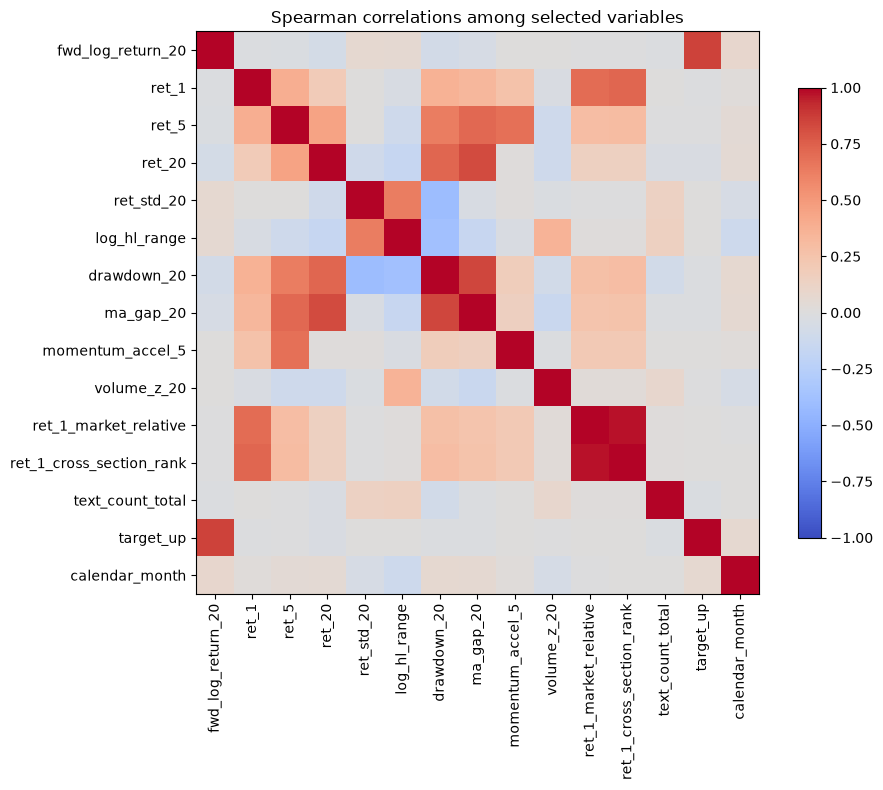

In [47]:
analysis_cols = [ 'fwd_log_return_20',
    "ret_1", "ret_5", "ret_20", "ret_std_20", "log_hl_range",
    "drawdown_20", "ma_gap_20", "momentum_accel_5", "volume_z_20",
    "ret_1_market_relative", "ret_1_cross_section_rank", "text_count_total", "target_up", 'calendar_month',
]
complete = features.select(analysis_cols).drop_nulls()
ranked = complete.select([pl.col(c).rank().alias(c) for c in analysis_cols])
spearman = ranked.corr()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(spearman.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(analysis_cols)), analysis_cols, rotation=90)
ax.set_yticks(range(len(analysis_cols)), analysis_cols)
ax.set_title("Spearman correlations among selected variables")
fig.colorbar(image, ax=ax, shrink=0.8); plt.tight_layout()

target_correlations = features.select([
    pl.corr(c, "target_up", method="spearman").alias(c)
    for c in analysis_cols if c != "target_up"
]).transpose(include_header=True, header_name="feature", column_names=["spearman_with_target"]).with_columns(
    pl.col("spearman_with_target").abs().alias("absolute_correlation")
).sort("absolute_correlation", descending=True)
display(target_correlations)


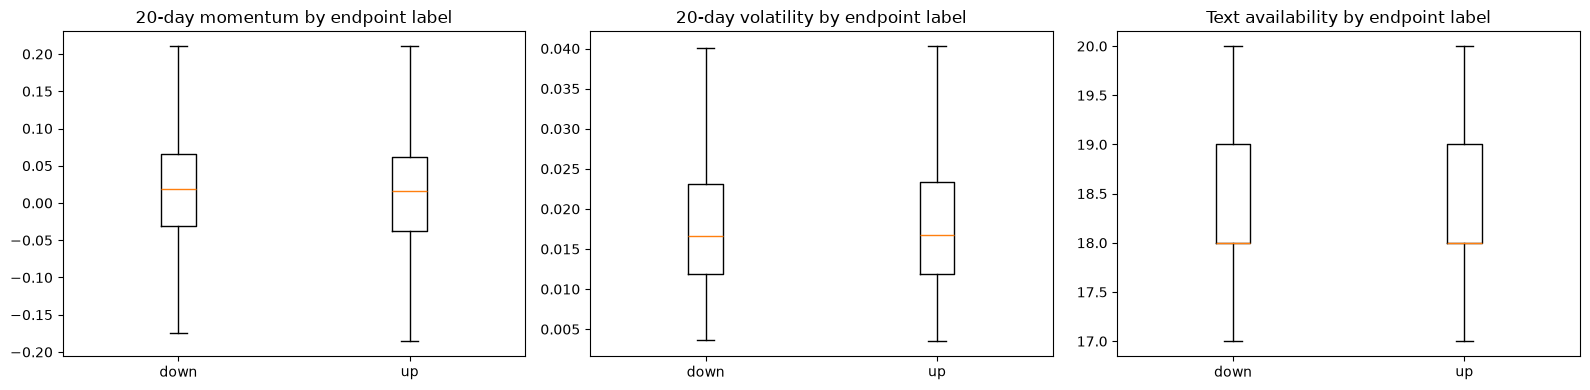

In [48]:
plot_pool = features.drop_nulls(["target_up", "ret_std_20", "drawdown_20"])
plot_sample = plot_pool.sample(n=min(20000, plot_pool.height), seed=RANDOM_STATE)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title in zip(
    axes, ["ret_20", "ret_std_20", "text_count_total"],
    ["20-day momentum", "20-day volatility", "Text availability"],
):
    down = plot_sample.filter(pl.col("target_up") == 0)[col].drop_nulls().to_numpy()
    up = plot_sample.filter(pl.col("target_up") == 1)[col].drop_nulls().to_numpy()
    ax.boxplot([down, up], tick_labels=["down", "up"], showfliers=False)
    ax.set_title(f"{title} by endpoint label")
plt.tight_layout()


## 7. Embedding stores, stock-date aggregation, and optional per-model PCA

Every valid embedding parquet is exposed as a lazy Polars scan with all of its dimensions, and `text_links` preserves the exact `(row_id, date, ticker, text_field, text_id)` identity of every token. For tabular models, articles are aggregated only within the same embedding family: after optional fold-fitted PCA, the notebook computes a dimension-wise mean over the distinct articles associated with each stock-date. The resulting family vectors are concatenated with one another and with the numeric features. Families are never averaged together. Rows without a usable family vector receive zeros, while text-count features retain the missing-news signal. Item-level tables remain available for attention models.

Collecting all six high-dimensional files into RAM would require tens of gigabytes, so models are scanned or streamed one at a time. `EMBEDDING_EXPORT` selects one reproducible output variant: `no_embeddings`, `original_embeddings`, or `pca_embeddings`. PCA is fitted independently for each model using only the text IDs referenced by a walk-forward training fold. The local LINQ parquet currently has an invalid footer and cannot be exposed until it is re-downloaded.


In [49]:
EMBEDDING_PATHS = {model: DATA_DIR / f"{model}_textemb.parquet" for model in EMBEDDING_MODELS}
embedding_scans = {}
embedding_catalog_rows = []
for model, path in EMBEDDING_PATHS.items():
    health = parquet_metadata(path)
    usable = path.exists() and health["status"] == "ok"
    if usable:
        embedding_scans[model] = pl.scan_parquet(path)
    embedding_catalog_rows.append({
        "model": model, "path": str(path), "usable": usable,
        "rows": health["rows"],
        "embedding_dimensions": health["columns"] - 1 if health["columns"] else None,
        "pca_components": PCA_COMPONENTS_BY_MODEL[model],
        "status": health["status"],
    })
embedding_catalog = pl.DataFrame(embedding_catalog_rows, infer_schema_length=None)
display(embedding_catalog)
print("Usable lazy embedding stores:", sorted(embedding_scans))

def iter_embedding_row_groups(model, referenced_ids=None, row_group_order=None):
    """Yield full-dimensional Polars batches without aggregating or truncating."""
    if model not in embedding_scans:
        raise ValueError(f"Embedding model {model!r} is unavailable or corrupt.")
    pf = pq.ParquetFile(EMBEDDING_PATHS[model])
    referenced_ids = None if referenced_ids is None else list(referenced_ids)
    order = list(range(pf.metadata.num_row_groups)) if row_group_order is None else list(row_group_order)
    for row_group in order:
        batch = pl.from_arrow(pf.read_row_group(row_group))
        if referenced_ids is not None:
            batch = batch.filter(pl.col("text_id").is_in(referenced_ids))
        if batch.height:
            yield batch
        del batch
        gc.collect()

def collect_embedding_model(model, referenced_ids=None):
    """Materialize one full-dimensional model only; this can require many GB."""
    batches = list(iter_embedding_row_groups(model, referenced_ids))
    return pl.concat(batches).unique("text_id") if batches else pl.DataFrame()

def fit_incremental_pca_for_model(model, training_text_ids, n_components, batch_size=4096, random_state=42):
    """Fit one model's PCA on full vectors referenced by one training fold."""
    if not isinstance(n_components, int) or n_components <= 0:
        raise ValueError("n_components must be a positive integer.")
    transformer = IncrementalPCA(n_components=n_components, batch_size=batch_size)
    rng = np.random.default_rng(random_state)
    pf = pq.ParquetFile(EMBEDDING_PATHS[model])
    row_group_order = rng.permutation(pf.metadata.num_row_groups)
    pending = None
    fitted_batches = 0
    for batch in iter_embedding_row_groups(model, training_text_ids, row_group_order):
        embedding_cols = [c for c in batch.columns if c.startswith("emb_")]
        values = batch.select(embedding_cols).to_numpy().astype(np.float32, copy=False)
        values = values[rng.permutation(len(values))]
        if pending is not None and len(pending):
            values = np.concatenate([pending, values], axis=0)
        cursor = 0
        while len(values) - cursor >= batch_size + n_components:
            transformer.partial_fit(values[cursor:cursor + batch_size])
            fitted_batches += 1
            cursor += batch_size
        pending = values[cursor:].copy()
    if pending is not None and len(pending) >= n_components:
        transformer.partial_fit(pending)
        fitted_batches += 1
    if fitted_batches == 0:
        raise ValueError("No embedding batch had enough referenced rows to fit PCA.")
    return transformer

def transform_embedding_model(model, transformer, referenced_ids=None):
    """Return one row per text_id; PCA changes dimensions but never pools texts."""
    pieces = []
    for batch in iter_embedding_row_groups(model, referenced_ids):
        embedding_cols = [c for c in batch.columns if c.startswith("emb_")]
        projected = transformer.transform(batch.select(embedding_cols).to_numpy()).astype(np.float32)
        projected_frame = pl.DataFrame(projected, schema=[f"{model}_pc_{j:03d}" for j in range(projected.shape[1])])
        pieces.append(pl.concat([batch.select("text_id"), projected_frame], how="horizontal_extend"))
    return pl.concat(pieces).unique("text_id") if pieces else pl.DataFrame()

def map_text_tokens_to_embeddings(token_links, embedding_table, model):
    """Direct text_id join that preserves every field-level token."""
    value_cols = [c for c in embedding_table.columns if c != "text_id"]
    renamed = embedding_table.rename({c: f"{model}__{c}" for c in value_cols})
    return token_links.join(renamed, on="text_id", how="left")

def aggregate_articles_within_model(token_links, embedding_table, model):
    """Mean-pool distinct articles within one embedding family for each row_id."""
    unique_links = token_links.select(["row_id", "text_id"]).unique()
    mapped = map_text_tokens_to_embeddings(unique_links, embedding_table, model)
    value_cols = [c for c in mapped.columns if c.startswith(f"{model}__")]
    if not value_cols:
        return pl.DataFrame({"row_id": []}, schema={"row_id": pl.UInt32})
    return mapped.group_by("row_id").agg(
        [pl.col(c).mean().cast(pl.Float32).alias(c) for c in value_cols]
    )

def append_familywise_article_means(row_features, token_links, model_tables):
    """Append one article-mean vector per model family; never average families."""
    result = row_features
    scoped_links = token_links.filter(pl.col("row_id").is_in(row_features["row_id"]))
    added_columns = []
    for model, table in model_tables.items():
        aggregated = aggregate_articles_within_model(scoped_links, table, model)
        model_columns = [c for c in aggregated.columns if c != "row_id"]
        result = result.join(aggregated, on="row_id", how="left")
        added_columns.extend(model_columns)
    if added_columns:
        result = result.with_columns(pl.col(added_columns).fill_null(0.0))
    return result


model,path,usable,rows,embedding_dimensions,pca_components,status
str,str,bool,null,null,i64,str
"""b""","""data/b_textemb.parquet""",false,null,null,32,"""ERROR: FileNotFoundError: [Err…"
"""e""","""data/e_textemb.parquet""",false,null,null,32,"""ERROR: FileNotFoundError: [Err…"
"""r""","""data/r_textemb.parquet""",false,null,null,32,"""ERROR: FileNotFoundError: [Err…"
"""t""","""data/t_textemb.parquet""",false,null,null,32,"""ERROR: FileNotFoundError: [Err…"


Usable lazy embedding stores: []


In [50]:
print(f"Embedding export variant: {EMBEDDING_EXPORT}; usable lazy stores: {sorted(embedding_scans)}")


Embedding export variant: pca_embeddings; usable lazy stores: []


## 8. Purged walk-forward fold preparation

A single chronological split is not used. This prepares expanding-window indices for later modeling. Every fold leaves 20 trading dates between training and validation origins. Imputation, scaling, feature selection, and embedding PCA must be refitted inside every training fold.


In [51]:
def make_purged_walk_forward_folds(frame, n_splits=5, purge_dates=20, min_train_dates=None):
    dates = frame["date"].unique().sort().to_list()
    if min_train_dates is None:
        min_train_dates = max(2 * purge_dates + 1, len(dates) // 4)
    available = len(dates) - min_train_dates - purge_dates
    if available < n_splits:
        raise ValueError("Not enough dates for the requested training window, purge, and folds.")
    validation_dates = available // n_splits
    folds, summaries = [], []
    date_series = frame["date"]

    for fold in range(n_splits):
        validation_start_pos = min_train_dates + purge_dates + fold * validation_dates
        validation_end_pos = len(dates) if fold == n_splits - 1 else validation_start_pos + validation_dates
        train_end_pos = validation_start_pos - purge_dates
        train_dates = dates[:train_end_pos]
        validation_block = dates[validation_start_pos:validation_end_pos]
        train_idx = date_series.is_in(train_dates).arg_true().to_numpy()
        validation_idx = date_series.is_in(validation_block).arg_true().to_numpy()
        folds.append((train_idx, validation_idx))
        summaries.append({
            "fold": fold + 1, "train_start": train_dates[0], "train_end": train_dates[-1],
            "validation_start": validation_block[0], "validation_end": validation_block[-1],
            "train_dates": len(train_dates), "purged_dates": purge_dates,
            "validation_dates": len(validation_block),
            "train_rows": len(train_idx), "validation_rows": len(validation_idx),
        })
    return folds, pl.DataFrame(summaries)

labeled = features.with_row_index("row_id").filter(pl.col("target_up").is_not_null())
walk_forward_folds, fold_summary = make_purged_walk_forward_folds(labeled, n_splits=5, purge_dates=HORIZON)
display(fold_summary)

def text_ids_for_fold(token_links, labeled_frame, row_indices):
    """Return unique text IDs referenced by selected labeled rows."""
    row_ids = labeled_frame[row_indices]["row_id"].to_list()
    return set(
        token_links.filter(pl.col("row_id").is_in(row_ids))["text_id"]
        .unique().to_list()
    )

# Example: get training/validation IDs without loading any embedding matrix.
first_train_idx, first_validation_idx = walk_forward_folds[0]
first_fold_train_text_ids = text_ids_for_fold(text_links, labeled, first_train_idx)
first_fold_validation_text_ids = text_ids_for_fold(text_links, labeled, first_validation_idx)
print(f"Fold 1 references {len(first_fold_train_text_ids):,} training text IDs and {len(first_fold_validation_text_ids):,} validation text IDs.")

# Executable embedding pipeline. Every table remains keyed by text_id; texts are never pooled.
fold_pca_transformers = {}
fold_embedding_tables = {}
final_pca_transformers = {}
final_train_embedding_tables = {}
test_embedding_tables = {}

if LOAD_EMBEDDINGS:
    usable_models = [model for model in EMBEDDING_MODELS if model in embedding_scans]
    for fold_number, (train_idx, validation_idx) in enumerate(walk_forward_folds, start=1):
        train_ids = text_ids_for_fold(text_links, labeled, train_idx)
        validation_ids = text_ids_for_fold(text_links, labeled, validation_idx)
        needed_ids = train_ids | validation_ids
        fold_pca_transformers[fold_number] = {}
        fold_embedding_tables[fold_number] = {}
        for model in usable_models:
            n_components = PCA_COMPONENTS_BY_MODEL[model]
            if n_components is None:
                table = collect_embedding_model(model, referenced_ids=needed_ids)
            else:
                transformer = fit_incremental_pca_for_model(
                    model, train_ids, n_components, PCA_BATCH_SIZE,
                    random_state=RANDOM_STATE + fold_number,
                )
                fold_pca_transformers[fold_number][model] = transformer
                table = transform_embedding_model(model, transformer, referenced_ids=needed_ids)
            fold_embedding_tables[fold_number][model] = table
            print(f"fold={fold_number} model={model} rows={table.height:,} dimensions={table.width - 1}")

    # Final transformers use every training-file text ID, never test-only IDs.
    all_train_text_ids = set(text_links["text_id"].unique().to_list())
    all_test_text_ids = set(test_text_links["text_id"].unique().to_list())
    for model in usable_models:
        n_components = PCA_COMPONENTS_BY_MODEL[model]
        if n_components is None:
            final_train_embedding_tables[model] = collect_embedding_model(model, all_train_text_ids)
            test_embedding_tables[model] = collect_embedding_model(model, all_test_text_ids)
        else:
            transformer = fit_incremental_pca_for_model(
                model, all_train_text_ids, n_components, PCA_BATCH_SIZE,
                random_state=RANDOM_STATE,
            )
            final_pca_transformers[model] = transformer
            final_train_embedding_tables[model] = transform_embedding_model(
                model, transformer, all_train_text_ids
            )
            test_embedding_tables[model] = transform_embedding_model(
                model, transformer, all_test_text_ids
            )
        print(
            f"final model={model} train_rows={final_train_embedding_tables[model].height:,} "
            f"test_rows={test_embedding_tables[model].height:,} dimensions={test_embedding_tables[model].width - 1}"
        )
else:
    print("Embedding collection skipped because LOAD_EMBEDDINGS=False.")

MODEL_FEATURE_COLS = [
    c for c, dtype in features.schema.items()
    if dtype.is_numeric() and c not in PRICE_COLS + ["log_close", "target_up", f"fwd_log_return_{HORIZON}", "fwd_log_return_20"]
]
print(f"Candidate numeric model features: {len(MODEL_FEATURE_COLS)}")
print(MODEL_FEATURE_COLS)


fold,train_start,train_end,validation_start,validation_end,train_dates,purged_dates,validation_dates,train_rows,validation_rows
i64,date,date,date,date,i64,i64,i64,i64,i64
1,2019-01-01,2019-12-24,2020-01-22,2020-08-17,256,20,149,25600,14900
2,2019-01-01,2020-07-20,2020-08-18,2021-03-12,405,20,149,40500,14900
3,2019-01-01,2021-02-12,2021-03-15,2021-10-07,554,20,149,55400,14900
4,2019-01-01,2021-09-09,2021-10-08,2022-05-04,703,20,149,70300,14900
5,2019-01-01,2022-04-06,2022-05-05,2022-12-02,852,20,152,85200,15200


Fold 1 references 113,324 training text IDs and 66,758 validation text IDs.
Candidate numeric model features: 106
['ret_1', 'log_hl_range', 'log_close_open', 'ret_5', 'ret_mean_5', 'ret_std_5', 'ma_gap_5', 'drawdown_5', 'ret_10', 'ret_mean_10', 'ret_std_10', 'ma_gap_10', 'drawdown_10', 'ret_20', 'ret_mean_20', 'ret_std_20', 'ma_gap_20', 'drawdown_20', 'ret_40', 'ret_mean_40', 'ret_std_40', 'ma_gap_40', 'drawdown_40', 'ret_60', 'ret_mean_60', 'ret_std_60', 'ma_gap_60', 'drawdown_60', 'momentum_accel_5', 'ret_skew_20', 'ret_kurt_20', 'ret_skew_60', 'ret_kurt_60', 'log_volume', 'volume_change_1', 'log_volume_mean_5', 'log_volume_std_5', 'log_volume_gap_5', 'volume_z_5', 'volume_ma_gap_5', 'log_volume_mean_10', 'log_volume_std_10', 'log_volume_gap_10', 'volume_z_10', 'volume_ma_gap_10', 'log_volume_mean_20', 'log_volume_std_20', 'log_volume_gap_20', 'volume_z_20', 'volume_ma_gap_20', 'log_volume_mean_40', 'log_volume_std_40', 'log_volume_gap_40', 'volume_z_40', 'volume_ma_gap_40', 'log_vol

## 9. Persist complete modeling artifacts

When `SAVE_ARTIFACTS=True`, this section writes the selected variant beneath `data/model_artifacts/<EMBEDDING_EXPORT>/`, so rerunning another variant does not overwrite earlier results. Filenames also state the representation explicitly: plain matrices end in `without_embeddings`, while embedding outputs contain `pca_embeddings` or `original_embeddings`; row-level tabular matrices additionally contain `article_mean`, and attention inputs contain `item_level`. Every variant contains separate train/test target tables, text links, walk-forward assignments, summaries, and configuration metadata. Test targets are derived from the close at $t+H$ when that future row exists; the final $H$ observations per ticker remain null.


In [52]:
if SAVE_ARTIFACTS:
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    train_feature_path = ARTIFACT_DIR / "train_features_without_embeddings.parquet"
    test_feature_path = ARTIFACT_DIR / "test_features_without_embeddings.parquet"
    train_target_path = ARTIFACT_DIR / "train_target.parquet"
    test_target_path = ARTIFACT_DIR / "test_target.parquet"
    test_index_path = ARTIFACT_DIR / "test_prediction_index.parquet"
    train_link_path = ARTIFACT_DIR / "train_text_links.parquet"
    test_link_path = ARTIFACT_DIR / "test_text_links.parquet"

    export_cols = list(dict.fromkeys(ID_COLS + MODEL_FEATURE_COLS))
    train_export = features.with_row_index("row_id").select(
        ["row_id"] + [c for c in export_cols if c in features.columns]
    )
    test_export_cols = ID_COLS + [c for c in MODEL_FEATURE_COLS if c in test_features.columns]
    test_export = test_features.with_row_index("row_id").select(["row_id"] + test_export_cols)
    train_export.write_parquet(train_feature_path, compression="zstd")
    test_export.write_parquet(test_feature_path, compression="zstd")
    features.with_row_index("row_id").select(
        ["row_id"] + ID_COLS + [f"fwd_log_return_{HORIZON}", "target_up"]
    ).write_parquet(train_target_path, compression="zstd")
    test_features.with_row_index("row_id").select(
        ["row_id"] + ID_COLS + [f"fwd_log_return_{HORIZON}", "target_up"]
    ).write_parquet(test_target_path, compression="zstd")
    test_export.select(["row_id"] + ID_COLS).write_parquet(test_index_path, compression="zstd")
    text_links.write_parquet(train_link_path, compression="zstd")
    test_text_links.write_parquet(test_link_path, compression="zstd")

    assignment_parts = []
    for fold_number, (train_idx, validation_idx) in enumerate(walk_forward_folds, start=1):
        for split_name, indices in (("train", train_idx), ("validation", validation_idx)):
            assignment_parts.append(
                labeled[indices].select(["row_id", "date", "ticker"]).with_columns(
                    pl.lit(fold_number).cast(pl.Int8).alias("fold"),
                    pl.lit(split_name).alias("split"),
                )
            )
    fold_assignments = pl.concat(assignment_parts).select(
        ["fold", "split", "row_id", "date", "ticker"]
    ).sort(["fold", "split", "date", "ticker"])
    fold_assignments.write_parquet(ARTIFACT_DIR / "walk_forward_assignments.parquet", compression="zstd")
    fold_summary.write_parquet(ARTIFACT_DIR / "walk_forward_summary.parquet", compression="zstd")
    embedding_catalog.write_parquet(ARTIFACT_DIR / "embedding_catalog.parquet", compression="zstd")

    configuration = {
        "horizon": HORIZON, "windows": list(WINDOWS),
        "trading_week_fourier_harmonics": TRADING_WEEK_FOURIER_HARMONICS,
        "month_of_year_fourier_harmonics": MONTH_OF_YEAR_FOURIER_HARMONICS,
        "trading_month_fourier_harmonics": TRADING_MONTH_FOURIER_HARMONICS,
        "embedding_export": EMBEDDING_EXPORT,
        "load_embeddings": LOAD_EMBEDDINGS,
        "embedding_models": list(EMBEDDING_MODELS),
        "pca_components_by_model": PCA_COMPONENTS_BY_MODEL,
        "pca_batch_size": PCA_BATCH_SIZE,
        "embedding_aggregation": "mean_articles_within_each_model_then_concatenate_models",
        "model_feature_columns": MODEL_FEATURE_COLS,
    }
    (ARTIFACT_DIR / "configuration.json").write_text(json.dumps(configuration, indent=2))

    if LOAD_EMBEDDINGS:
        for fold_number, model_tables in fold_embedding_tables.items():
            fold_dir = ARTIFACT_DIR / "embeddings" / f"fold_{fold_number}"
            fold_dir.mkdir(parents=True, exist_ok=True)
            for model, table in model_tables.items():
                table.write_parquet(
                    fold_dir / f"{model}_item_level_{EMBEDDING_EXPORT}.parquet", compression="zstd"
                )
            for model, transformer in fold_pca_transformers[fold_number].items():
                joblib.dump(transformer, fold_dir / f"{model}_pca_transformer.joblib")
            fold_train = labeled[walk_forward_folds[fold_number - 1][0]].select(
                ["row_id"] + [c for c in export_cols if c in labeled.columns]
            )
            fold_validation = labeled[walk_forward_folds[fold_number - 1][1]].select(
                ["row_id"] + [c for c in export_cols if c in labeled.columns]
            )
            append_familywise_article_means(fold_train, text_links, model_tables).write_parquet(
                fold_dir / f"train_features_with_article_mean_{EMBEDDING_EXPORT}.parquet", compression="zstd"
            )
            append_familywise_article_means(fold_validation, text_links, model_tables).write_parquet(
                fold_dir / f"validation_features_with_article_mean_{EMBEDDING_EXPORT}.parquet", compression="zstd"
            )

        final_dir = ARTIFACT_DIR / "embeddings" / "final"
        final_dir.mkdir(parents=True, exist_ok=True)
        for model, table in final_train_embedding_tables.items():
            table.write_parquet(
                final_dir / f"{model}_train_item_level_{EMBEDDING_EXPORT}.parquet", compression="zstd"
            )
        for model, table in test_embedding_tables.items():
            table.write_parquet(
                final_dir / f"{model}_test_item_level_{EMBEDDING_EXPORT}.parquet", compression="zstd"
            )
        for model, transformer in final_pca_transformers.items():
            joblib.dump(transformer, final_dir / f"{model}_pca_transformer.joblib")
        append_familywise_article_means(train_export, text_links, final_train_embedding_tables).write_parquet(
            ARTIFACT_DIR / f"train_features_with_article_mean_{EMBEDDING_EXPORT}.parquet", compression="zstd"
        )
        append_familywise_article_means(test_export, test_text_links, test_embedding_tables).write_parquet(
            ARTIFACT_DIR / f"test_features_with_article_mean_{EMBEDDING_EXPORT}.parquet", compression="zstd"
        )

    artifact_rows = [
        {"path": str(path.relative_to(ARTIFACT_DIR)), "size_bytes": path.stat().st_size}
        for path in sorted(ARTIFACT_DIR.rglob("*")) if path.is_file() and path.name != "manifest.json"
    ]
    artifact_manifest = {"embedding_export": EMBEDDING_EXPORT, "files": artifact_rows}
    (ARTIFACT_DIR / "manifest.json").write_text(json.dumps(artifact_manifest, indent=2))
    print(f"Saved {len(artifact_rows)} artifacts under {ARTIFACT_DIR} ({sum(x['size_bytes'] for x in artifact_rows) / 1024**2:.1f} MB).")
else:
    print("Artifact persistence skipped because SAVE_ARTIFACTS=False.")


/var/folders/sy/6qs34m5j4nxc0dx977v1j2700000gn/T/ipykernel_8016/2121554246.py:100: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  scoped_links = token_links.filter(pl.col("row_id").is_in(row_features["row_id"]))


Saved 23 artifacts under data/model_artifacts/pca_embeddings (186.6 MB).


## Modeling handoff

Continue in `baseline_models.ipynb`, which loads the artifacts saved above rather than recomputing features.

1. Use purged walk-forward validation; never randomly shuffle stock-date rows.
2. Fit imputation, scaling, embedding PCA, and feature selection within each fold's training period.
3. Start with always-up, momentum/reversal, $L_2$ logistic regression, LightGBM, CatBoost, XGBoost, and TabPFN.
4. Report hit rate overall and by date, ticker, year, volatility regime, and target class.
5. Compare price-only features, price plus text coverage, and price plus fold-specific PCA embeddings.
6. Ablate raw calendar fields, trading-week Fourier terms, month-of-year Fourier terms, and within-trading-month Fourier terms separately.
